In [ ]:
from google.colab import drive
import os
import fnmatch
import struct
import collections
import matplotlib.pyplot as plt
import struct
import numpy as np
import pandas as pd
from scipy.fft import fft, fftfreq
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
dat_files = []
for root, dirnames, filenames in os.walk('/content/drive'):
    for filename in fnmatch.filter(filenames, '*.dat'):
        dat_files.append(os.path.join(root, filename))

if dat_files:
    print('Found .dat files:')
    for f in dat_files:
        print(f)
else:
    print('No .dat files found in your Google Drive.')

No .dat files found in your Google Drive.


In [ ]:
def read_raw(file_path):
    with open(file_path, 'rb') as f:
        header_bytes = f.read(16)
        print(f"First 16 bytes (hex): {header_bytes.hex()}")
        try:
            int_val1, int_val2 = struct.unpack('<ii', header_bytes[:8])
            print(f"little-endian integers: {int_val1}, {int_val2}")
        except struct.error as e:
            print(f"Could not unpack bytes with chosen format: {e}.")
        next_10k_bytes = f.read(10000)
        print(f"Next 10000 bytes (hex): {next_10k_bytes.hex()}")
        return header_bytes , next_10k_bytes

First 16 bytes (hex): 00d5bbeddf29291c7300000301242423
Interpreted as two 4-byte little-endian integers: -306457344, 472459743
Next 10000 bytes (hex): ...


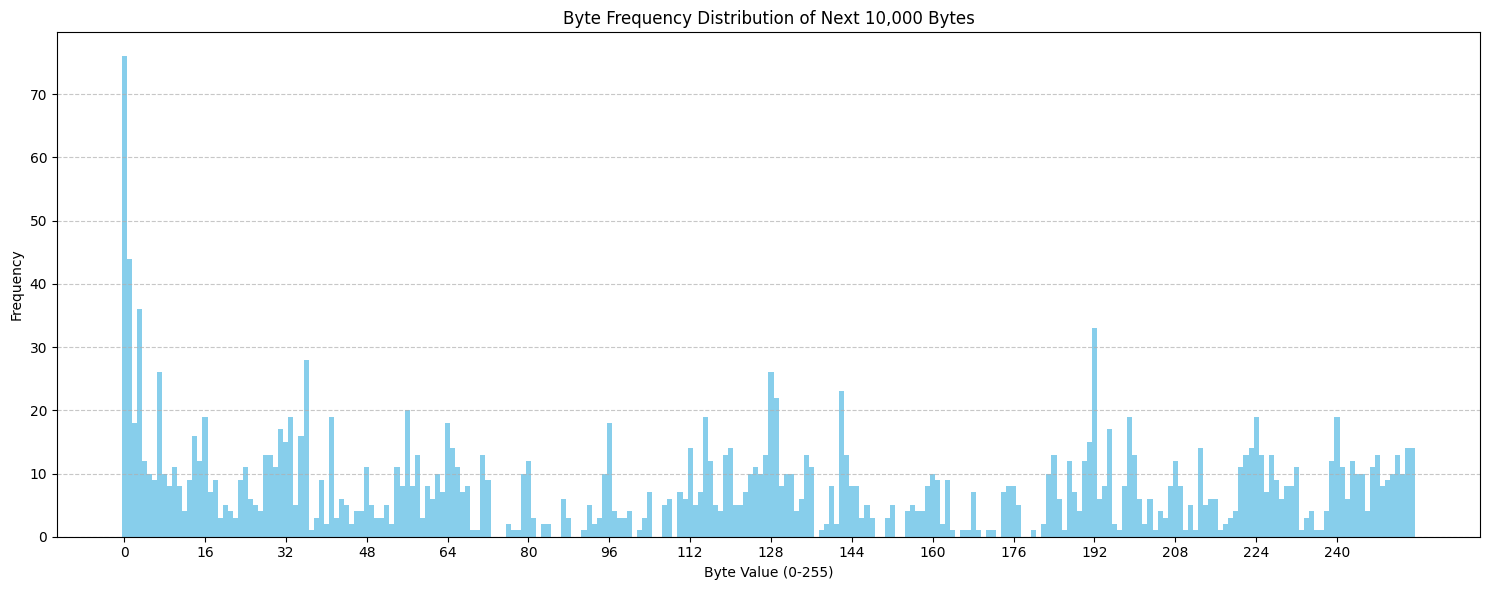

In [ ]:

header , next_10k_bytes_hex_string = read_raw("user6-1-1-1-1-r1.dat") 
raw_bytes = bytes.fromhex(next_10k_bytes_hex_string)
byte_counts = collections.Counter(raw_bytes)
byte_values = list(range(256))
frequencies = [byte_counts[b] for b in byte_values]

plt.figure(figsize=(15, 6))
plt.bar(byte_values, frequencies, width=1.0, color='skyblue')
plt.title('Byte Frequency Distribution of Next 10,000 Bytes')
plt.xlabel('Byte Value (0-255)')
plt.ylabel('Frequency')
plt.xticks(range(0, 256, 16))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Understanding `struct.unpack` Format Strings:

*   `'<'` or `'>'` specify byte order (little-endian or big-endian).
*   `'b'`, `'B'`: signed/unsigned char (1 byte)
*   `'h'`, `'H'`: signed/unsigned short (2 bytes)
*   `'i'`, `'I'`: signed/unsigned int (4 bytes)
*   `'l'`, `'L'`: signed/unsigned long (4 bytes on most systems)
*   `'q'`, `'Q'`: signed/unsigned long long (8 bytes)
*   `'f'`: float (4 bytes)
*   `'d'`: double (8 bytes)


You'll need specific documentation or knowledge of the `user6-1-1-1-1-r1.dat` file format to correctly interpret its binary content. Without that information, it's a process of educated guesswork and trying different structures.

In [ ]:
def read_widar_dat(file_path):
    csi_frames = []

    with open(file_path, "rb") as f:
        while True:
            len_bytes = f.read(2)
            if not len_bytes or len(len_bytes) < 2:
                break
            field_len = struct.unpack(">H", len_bytes)[0]
            if field_len == 0:
                continue
            payload = f.read(field_len)
            if len(payload) < field_len:
                break
            code = payload[0]
            if code == 187:
                timestamp = struct.unpack(">I", payload[1:5])[0]
                n_rx = payload[8]
                n_tx = payload[9]
                num_subcarriers = 30
                csi_payload = payload[20:]

                csi_matrix = np.zeros((n_tx, n_rx, num_subcarriers), dtype=complex)
                bit_index = 0

                try:
                    for sub_idx in range(num_subcarriers):
                        for rx_idx in range(n_rx):
                            for tx_idx in range(n_tx):
                                byte_idx = bit_index // 8
                                bit_rem = bit_index % 8

                                b1 = csi_payload[byte_idx]
                                b2 = csi_payload[byte_idx + 1]
                                imag = ((b1 >> bit_rem) | (b2 << (8 - bit_rem))) & 0x03FF
                                if imag >= 512: imag -= 1024
                                bit_index += 10
                                byte_idx = bit_index // 8
                                bit_rem = bit_index % 8

                                b1 = csi_payload[byte_idx]
                                b2 = csi_payload[byte_idx + 1]
                                real = ((b1 >> bit_rem) | (b2 << (8 - bit_rem))) & 0x03FF
                                if real >= 512: real -= 1024
                                bit_index += 10
                                csi_matrix[tx_idx, rx_idx, sub_idx] = complex(real, imag)

                    csi_frames.append({
                        "timestamp": timestamp,
                        "n_tx": n_tx,
                        "n_rx": n_rx,
                        "csi": csi_matrix
                    })
                except IndexError:
                    continue

    return csi_frames

file_name = "user6-1-1-1-1-r1.dat"
data_packets = read_widar_dat(file_name)

print(f"Successfully read {len(data_packets)} CSI packets.")
if len(data_packets) > 0:
    print("Shape of first CSI frame matrix:", data_packets[0]["csi"].shape)


Successfully read 1452 CSI packets.
Shape of first CSI frame matrix: (3, 0, 30)


In [ ]:
def scan_csi_file(file_path):
    print(f"--- DIAGNOSTIC SCAN FOR: {file_path} ---")

    with open(file_path, "rb") as f:
        raw_data = f.read()

    total_bytes = len(raw_data)
    print(f"Total file size: {total_bytes} bytes")

    if total_bytes == 0:
        print("ERROR: File is completely empty!")
        return

    bb_indices = [i for i, byte in enumerate(raw_data[:5000]) if byte == 187]
    print(f"Found {len(bb_indices)} instances of 0xBB (187) in the first 5000 bytes.")

    if not bb_indices:
        print("CRITICAL: No 0xBB marker bytes found.")
        print("Raw Hex:", raw_data[:30].hex())
        return
    for idx, b_pos in enumerate(bb_indices[:3]):
        print(f"\n--- Analysis of 0xBB Instance #{idx+1} at Byte Position: {b_pos} ---")
        if b_pos >= 2:
            len_big = struct.unpack(">H", raw_data[b_pos-2:b_pos])[0]
            len_lit = struct.unpack("<H", raw_data[b_pos-2:b_pos])[0]
            print(f"Bytes right BEFORE 0xBB (as Big-Endian Short): {len_big}")
            print(f"Bytes right BEFORE 0xBB (as Little-Endian Short): {len_lit}")

        after_bytes = raw_data[b_pos+1:b_pos+25]
        print(f"Next 24 bytes in Hex: {after_bytes.hex()}")

        if b_pos == 2 and len(raw_data) > 30:
            print("Assuming standard format where 0xBB is index 2:")
            print(f"  Byte 8 (N_Rx): {raw_data[8]}")
            print(f"  Byte 9 (N_Tx): {raw_data[9]}")
            print(f"  Byte 18-19 (CSI Length): {struct.unpack('>H', raw_data[18:20])[0]}")
scan_csi_file("user6-1-1-1-1-r1.dat")


--- DIAGNOSTIC SCAN FOR: user6-1-1-1-1-r1.dat ---
Total file size: 312180 bytes
Found 36 instances of 0xBB (187) in the first 5000 bytes.

--- Analysis of 0xBB Instance #1 at Byte Position: 2 ---
Bytes right BEFORE 0xBB (as Big-Endian Short): 213
Bytes right BEFORE 0xBB (as Little-Endian Short): 54528
Next 24 bytes in Hex: eddf29291c7300000301242423812321c0000101b057f7d7
Assuming standard format where 0xBB is index 2:
  Byte 8 (N_Rx): 115
  Byte 9 (N_Tx): 0
  Byte 18-19 (CSI Length): 8640

--- Analysis of 0xBB Instance #2 at Byte Position: 217 ---
Bytes right BEFORE 0xBB (as Big-Endian Short): 213
Bytes right BEFORE 0xBB (as Little-Endian Short): 54528
Next 24 bytes in Hex: d5e329291d7300000301272727812421c0000101607fd0e8

--- Analysis of 0xBB Instance #3 at Byte Position: 432 ---
Bytes right BEFORE 0xBB (as Big-Endian Short): 213
Bytes right BEFORE 0xBB (as Little-Endian Short): 54528
Next 24 bytes in Hex: b0e729291e7300000301242424812321c0000101a8c7b878


In [ ]:
def read_any_widar_dat_robust(file_path):
    csi_frames = []

    with open(file_path, "rb") as f:
        raw_data = f.read()

    total_bytes = len(raw_data)
    if total_bytes < 4:
        print("Error: File too small or empty.")
        return np.array([])
    initial_payload_len = struct.unpack(">H", raw_data[0:2])[0]
    dynamic_packet_size = initial_payload_len + 2

    first_packet = raw_data[0:dynamic_packet_size]

    raw_n_rx = first_packet[10]
    raw_n_tx = first_packet[11]
    num_subcarriers = 30

    # this part is due to INTEL 5300 have 3 antenna cross valid
    if raw_n_rx == 0 or raw_n_rx > 4:
        if raw_n_tx == 3:
            dynamic_n_tx = 1
            dynamic_n_rx = 3
        else:
            dynamic_n_tx = 1
            dynamic_n_rx = 3
    else:
        dynamic_n_tx = raw_n_tx
        dynamic_n_rx = raw_n_rx

    num_packets = total_bytes // dynamic_packet_size

    print("--- DETECTED & SANITISED FILE METADATA ---")
    print(f"File Path:                {file_path}")
    print(f"Total Packet Size:        {dynamic_packet_size} bytes")
    print(f"Sanitised Rx (n_rx):      {dynamic_n_rx} (Raw: {raw_n_rx})")
    print(f"Sanitised Tx (n_tx):      {dynamic_n_tx} (Raw: {raw_n_tx})")
    print(f"Total Processed Frames:   {num_packets} snapshots")
    print("-------------------------------------------\n")

    for i in range(num_packets):
        start_idx = i * dynamic_packet_size
        packet = raw_data[start_idx : start_idx + dynamic_packet_size]

        if packet[2] != 187:
            continue
        csi_payload = packet[25:]

        csi_matrix = np.zeros((dynamic_n_tx, dynamic_n_rx, num_subcarriers), dtype=complex)
        bit_index = 0

        for tx_idx in range(dynamic_n_tx):
            for rx_idx in range(dynamic_n_rx):
                for sub_idx in range(num_subcarriers):
                    try:
                        byte_idx = bit_index // 8
                        bit_rem = bit_index % 8
                        b1 = csi_payload[byte_idx]
                        b2 = csi_payload[byte_idx + 1]
                        imag = ((b1 >> bit_rem) | (b2 << (8 - bit_rem))) & 0x03FF
                        if imag >= 512: imag -= 1024
                        bit_index += 10
                        byte_idx = bit_index // 8
                        bit_rem = bit_index % 8
                        b1 = csi_payload[byte_idx]
                        b2 = csi_payload[byte_idx + 1]
                        real = ((b1 >> bit_rem) | (b2 << (8 - bit_rem))) & 0x03FF
                        if real >= 512: real -= 1024

                        bit_index += 10
                        csi_matrix[tx_idx, rx_idx, sub_idx] = complex(real, imag)
                    except IndexError:
                        break

        csi_frames.append(csi_matrix)

    return np.array(csi_frames)

file_name = "user6-1-1-1-1-r1.dat"
csi_dataset = read_any_widar_dat_robust(file_name)
print("Final Aligned Array Shape:", csi_dataset.shape)


--- DETECTED & SANITISED FILE METADATA ---
File Path:                user6-1-1-1-1-r1.dat
Total Packet Size:        215 bytes
Sanitised Rx (n_rx):      3 (Raw: 0)
Sanitised Tx (n_tx):      1 (Raw: 3)
Total Processed Frames:   1452 snapshots
-------------------------------------------

Final Aligned Array Shape: (1452, 1, 3, 30)


In [ ]:
def read_widar_dat_fixed_loops(file_path):
    n_tx = 1
    n_rx = 3
    num_subcarriers = 30
    packet_size = 215
    csi_frames = []

    with open(file_path, "rb") as f:
        raw_data = f.read()

    total_bytes = len(raw_data)
    num_packets = total_bytes // packet_size

    print(f"File size: {total_bytes} bytes. Expected packets: {num_packets}")

    for i in range(num_packets):
        start_idx = i * packet_size
        packet = raw_data[start_idx : start_idx + packet_size]

        if packet[2] != 187:
            continue
        csi_payload = packet[25:]

        csi_matrix = np.zeros((n_tx, n_rx, num_subcarriers), dtype=complex)
        bit_index = 0

        for tx_idx in range(n_tx):
            for rx_idx in range(n_rx):
                for sub_idx in range(num_subcarriers):
                    try:
                        byte_idx = bit_index // 8
                        bit_rem = bit_index % 8
                        b1 = csi_payload[byte_idx]
                        b2 = csi_payload[byte_idx + 1]
                        imag = ((b1 >> bit_rem) | (b2 << (8 - bit_rem))) & 0x03FF
                        if imag >= 512: imag -= 1024

                        bit_index += 10
                        byte_idx = bit_index // 8
                        bit_rem = bit_index % 8
                        b1 = csi_payload[byte_idx]
                        b2 = csi_payload[byte_idx + 1]
                        real = ((b1 >> bit_rem) | (b2 << (8 - bit_rem))) & 0x03FF
                        if real >= 512: real -= 1024

                        bit_index += 10
                        csi_matrix[tx_idx, rx_idx, sub_idx] = complex(real, imag)
                    except IndexError:
                        break

        csi_frames.append(csi_matrix)

    return np.array(csi_frames)

file_name = "user6-1-1-1-1-r1.dat"
csi_data = read_widar_dat_fixed_loops(file_name)

print(f"\nSuccessfully read {len(csi_data)} CSI packets.")
print("Shape of entire parsed dataset tensor:", csi_data.shape)


File size: 312180 bytes. Expected packets: 1452

Successfully read 1452 CSI packets.
Shape of entire parsed dataset tensor: (1452, 1, 3, 30)


In [ ]:

file_name = "user6-1-2-2-4-r2.dat"
csi_data = read_widar_dat_fixed_loops(file_name)

print(f"\nSuccessfully read {len(csi_data)} CSI packets.")
print("Shape of entire parsed dataset tensor:", csi_data.shape)

File size: 283370 bytes. Expected packets: 1318

Successfully read 1318 CSI packets.
Shape of entire parsed dataset tensor: (1318, 1, 3, 30)


In [ ]:
# absolute wave amplitude values as mentioned in spotfi paper for cfr
csi_amplitude = np.abs(csi_data)

# Flatten dimensions from (1452, 1, 3, 30) into a clean 2D layout matrix (1452, 90)
gan_inputs = csi_amplitude.reshape(csi_amplitude.shape[0], -1)
gan_inputs_normalized = (gan_inputs - gan_inputs.min()) / (gan_inputs.max() - gan_inputs.min())
print("Ready for GAN training. Normalized feature shape:", gan_inputs_normalized.shape)


Ready for GAN training. Normalized feature shape: (1452, 90)


CSI Matrix Shape: (3, 1, 25)


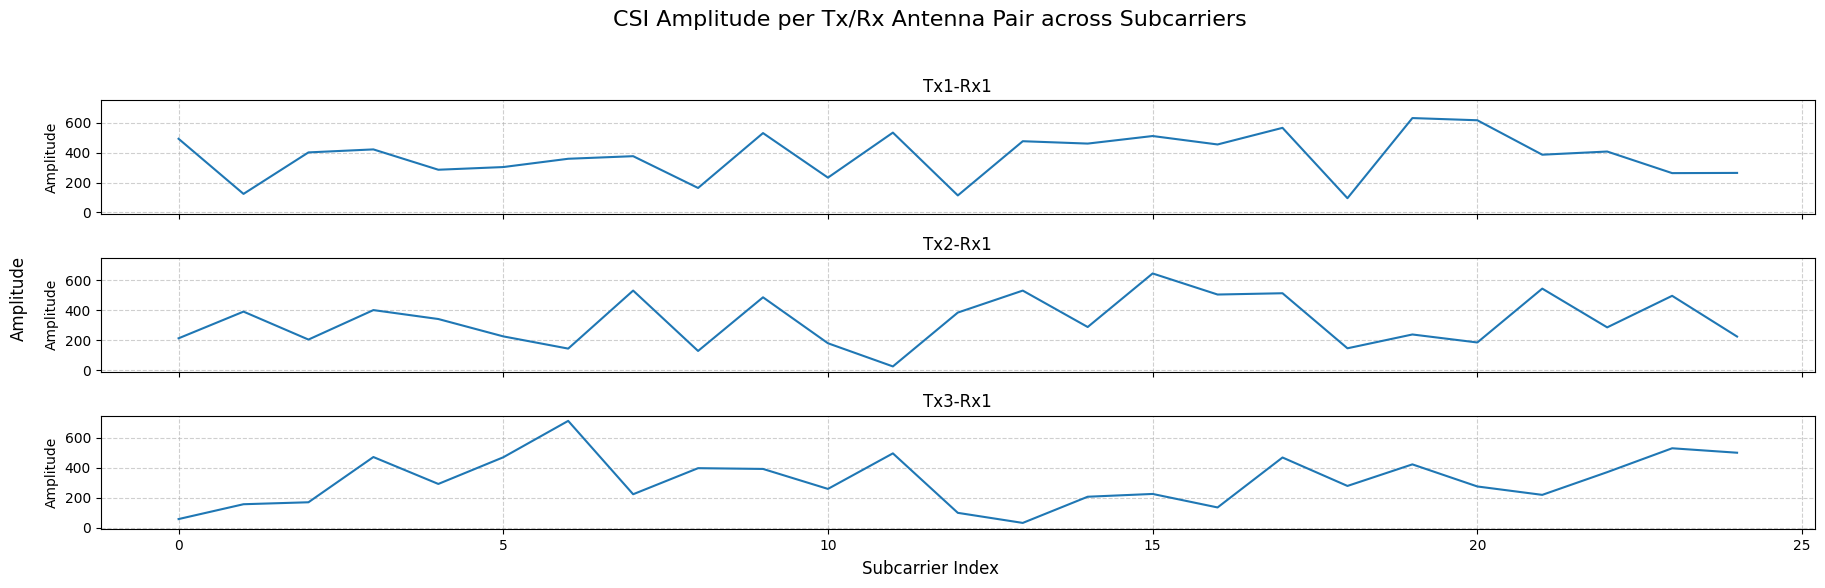

In [ ]:
if data_packets:
    first_packet = data_packets[0]
    csi_matrix = first_packet['csi']
    amplitude = np.abs(csi_matrix)
    n_tx, n_rx, num_subcarriers = csi_matrix.shape

    print(f"CSI Matrix Shape: {csi_matrix.shape}")
    fig, axes = plt.subplots(n_tx, n_rx, figsize=(num_subcarriers * 0.8, n_tx * n_rx * 2), sharex=True, sharey=True)

    if n_tx == 1 and n_rx == 1:
        axes = np.array([[axes]])
    elif n_tx == 1:
        axes = np.array([axes])
    elif n_rx == 1:
        axes = axes.reshape(n_tx, 1)
    fig.suptitle('CSI Amplitude per Tx/Rx Antenna Pair across Subcarriers', fontsize=16)

    for tx_idx in range(n_tx):
        for rx_idx in range(n_rx):
            ax = axes[tx_idx, rx_idx]
            ax.plot(amplitude[tx_idx, rx_idx, :])
            ax.set_title(f'Tx{tx_idx+1}-Rx{rx_idx+1}')
            ax.set_ylabel('Amplitude')
            ax.grid(True, linestyle='--', alpha=0.6)

    fig.text(0.5, 0.04, 'Subcarrier Index', ha='center', fontsize=12)
    fig.text(0.04, 0.5, 'Amplitude', va='center', rotation='vertical', fontsize=12)

    plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
    plt.show()

else:
    print("No CSI packets found to visualize.")

Preparing heatmaps for CSI Amplitude Heatmaps for user6-1-1-1-1-r1.dat: 1452 packets, 3 Tx, 1 Rx, 25 subcarriers.


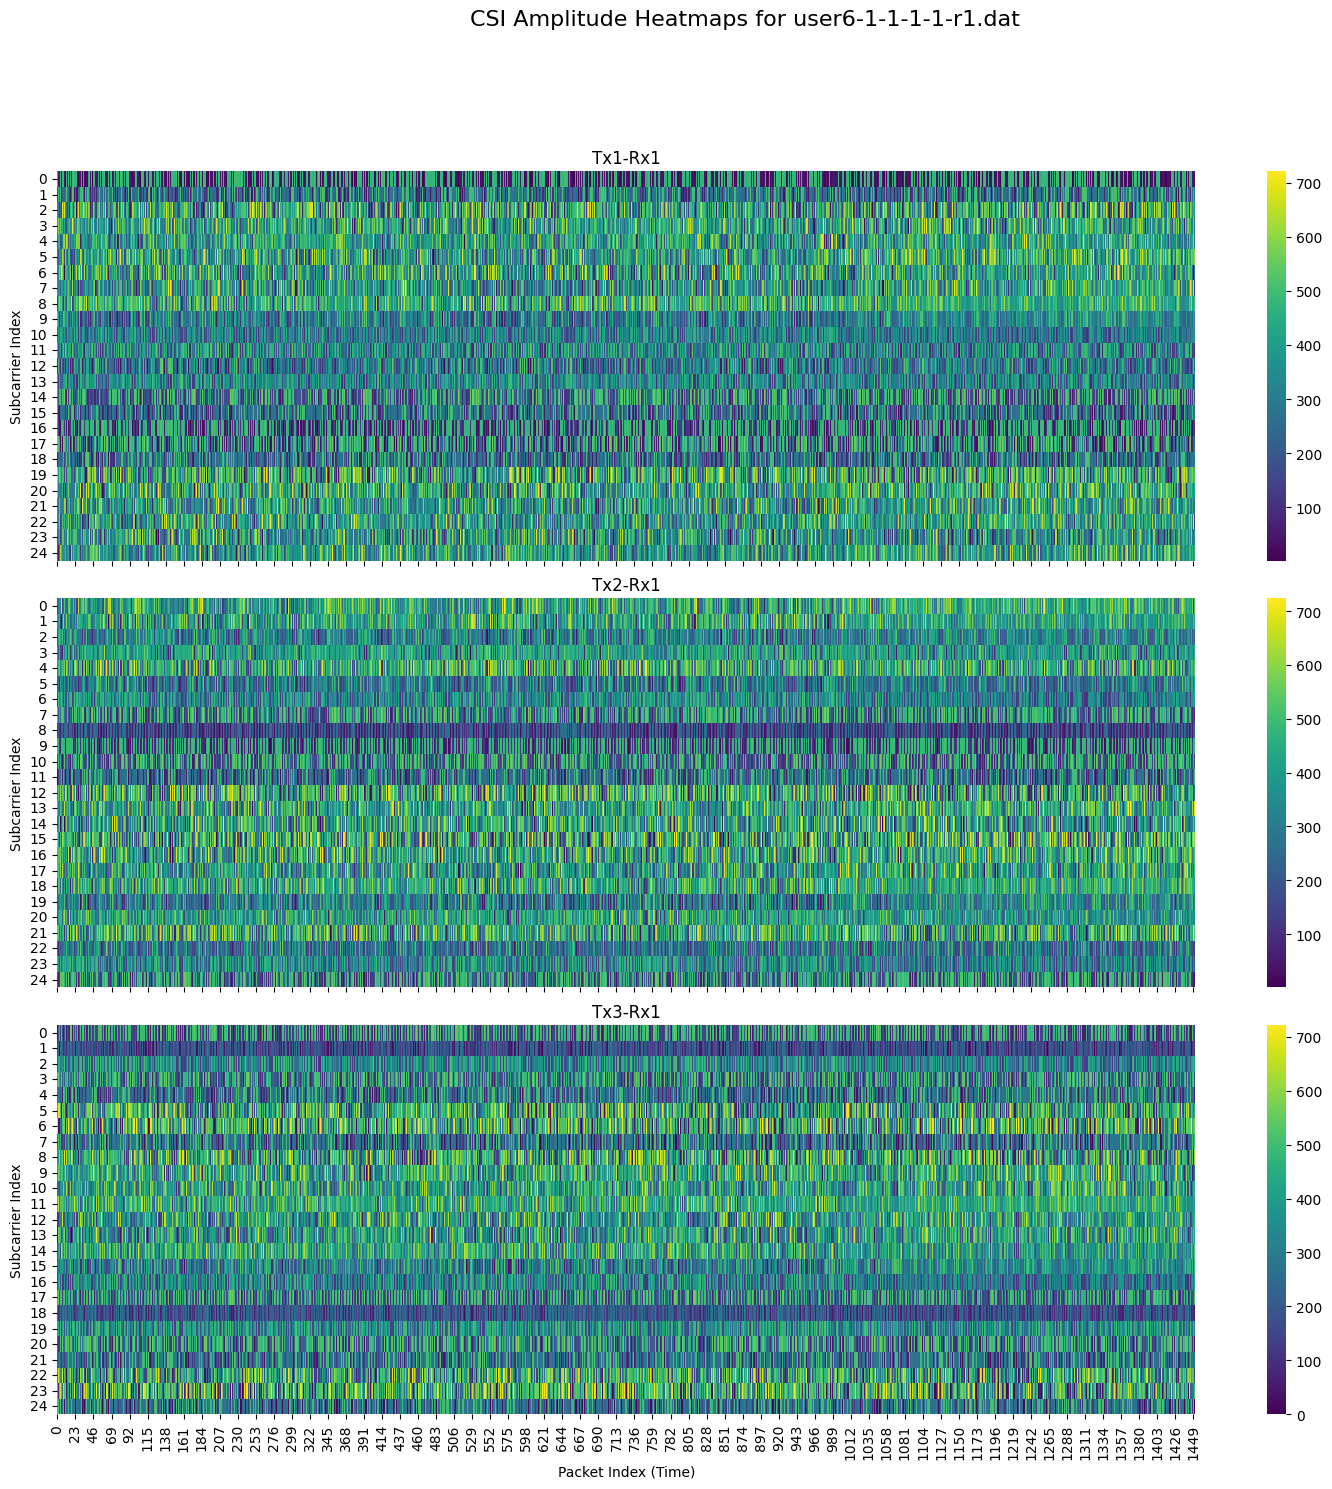

In [ ]:
def plot_csi_heatmaps(data_packets, plot_title):
    if not data_packets:
        print(f"No CSI : {plot_title}")
        return

    num_packets = len(data_packets)
    first_valid_packet = None
    for packet in data_packets:
        if packet["n_tx"] > 0 and packet["n_rx"] > 0:
            first_valid_packet = packet
            break

    if not first_valid_packet:
        print(f"No valid CSI : {plot_title}")
        return

    n_tx = first_valid_packet['n_tx']
    n_rx = first_valid_packet['n_rx']
    num_subcarriers = first_valid_packet['csi'].shape[2]

    print(f"Preparing heatmaps for {plot_title}: {num_packets} packets, {n_tx} Tx, {n_rx} Rx, {num_subcarriers} subcarriers.")

    all_amplitudes_per_pair = [np.zeros((num_subcarriers, num_packets)) for _ in range(n_tx * n_rx)]

    for packet_idx, packet in enumerate(data_packets):
        csi_matrix = packet['csi']
        if csi_matrix.shape == (n_tx, n_rx, num_subcarriers):
            amplitude = np.abs(csi_matrix)

            pair_idx = 0
            for tx_idx in range(n_tx):
                for rx_idx in range(n_rx):
                    all_amplitudes_per_pair[pair_idx][:, packet_idx] = amplitude[tx_idx, rx_idx, :]
                    pair_idx += 1
        else:
            # H as mentioned in paper WIFI survey
            print(f"Warning: Skipping packet {packet_idx} CSI matrix shape: {csi_matrix.shape}")

    fig, axes = plt.subplots(n_tx * n_rx, 1, figsize=(15, 5 * (n_tx * n_rx)), sharex=True)

    if n_tx * n_rx == 1:
        axes = [axes]

    fig.suptitle(plot_title, fontsize=16, y=1.02)

    pair_idx = 0
    for tx_idx in range(n_tx):
        for rx_idx in range(n_rx):
            ax = axes[pair_idx]
            sns.heatmap(all_amplitudes_per_pair[pair_idx], cmap='viridis', ax=ax, cbar=True, yticklabels=True)
            ax.set_title(f'Tx{tx_idx+1}-Rx{rx_idx+1}')
            ax.set_ylabel('Subcarrier Index')
            if pair_idx == (n_tx * n_rx) - 1:
                ax.set_xlabel('Packet Index (Time)')
            else:
                ax.set_xlabel('')
            pair_idx += 1

    plt.tight_layout(rect=[0.0, 0.03, 1, 0.96])
    plt.show()

plot_csi_heatmaps(data_packets, f'CSI Amplitude Heatmaps for {file_name}')

Preparing to generate heatmaps for 1 files.

Processing file: user6-1-1-1-1-r1.dat
--- Packet 1 ---
Field Length: 213
Code: 187 (0xBB)
Timestamp: 3990825257
Payload[8] (original N_Rx candidate): 0
Payload[9] (N_Tx candidate): 3
Payload[10] (new N_Rx candidate): 1
Payload bytes [5:17] (hex): 1c7300000301242423812321
-------------------
--- Packet 2 ---
Field Length: 213
Code: 187 (0xBB)
Timestamp: 3588434217
Payload[8] (original N_Rx candidate): 0
Payload[9] (N_Tx candidate): 3
Payload[10] (new N_Rx candidate): 1
Payload bytes [5:17] (hex): 1d7300000301272727812421
-------------------
--- Packet 3 ---
Field Length: 213
Code: 187 (0xBB)
Timestamp: 2967939369
Payload[8] (original N_Rx candidate): 0
Payload[9] (N_Tx candidate): 3
Payload[10] (new N_Rx candidate): 1
Payload bytes [5:17] (hex): 1e7300000301242424812321
-------------------
--- Packet 4 ---
Field Length: 213
Code: 187 (0xBB)
Timestamp: 2548771113
Payload[8] (original N_Rx candidate): 0
Payload[9] (N_Tx candidate): 3
Payload[10

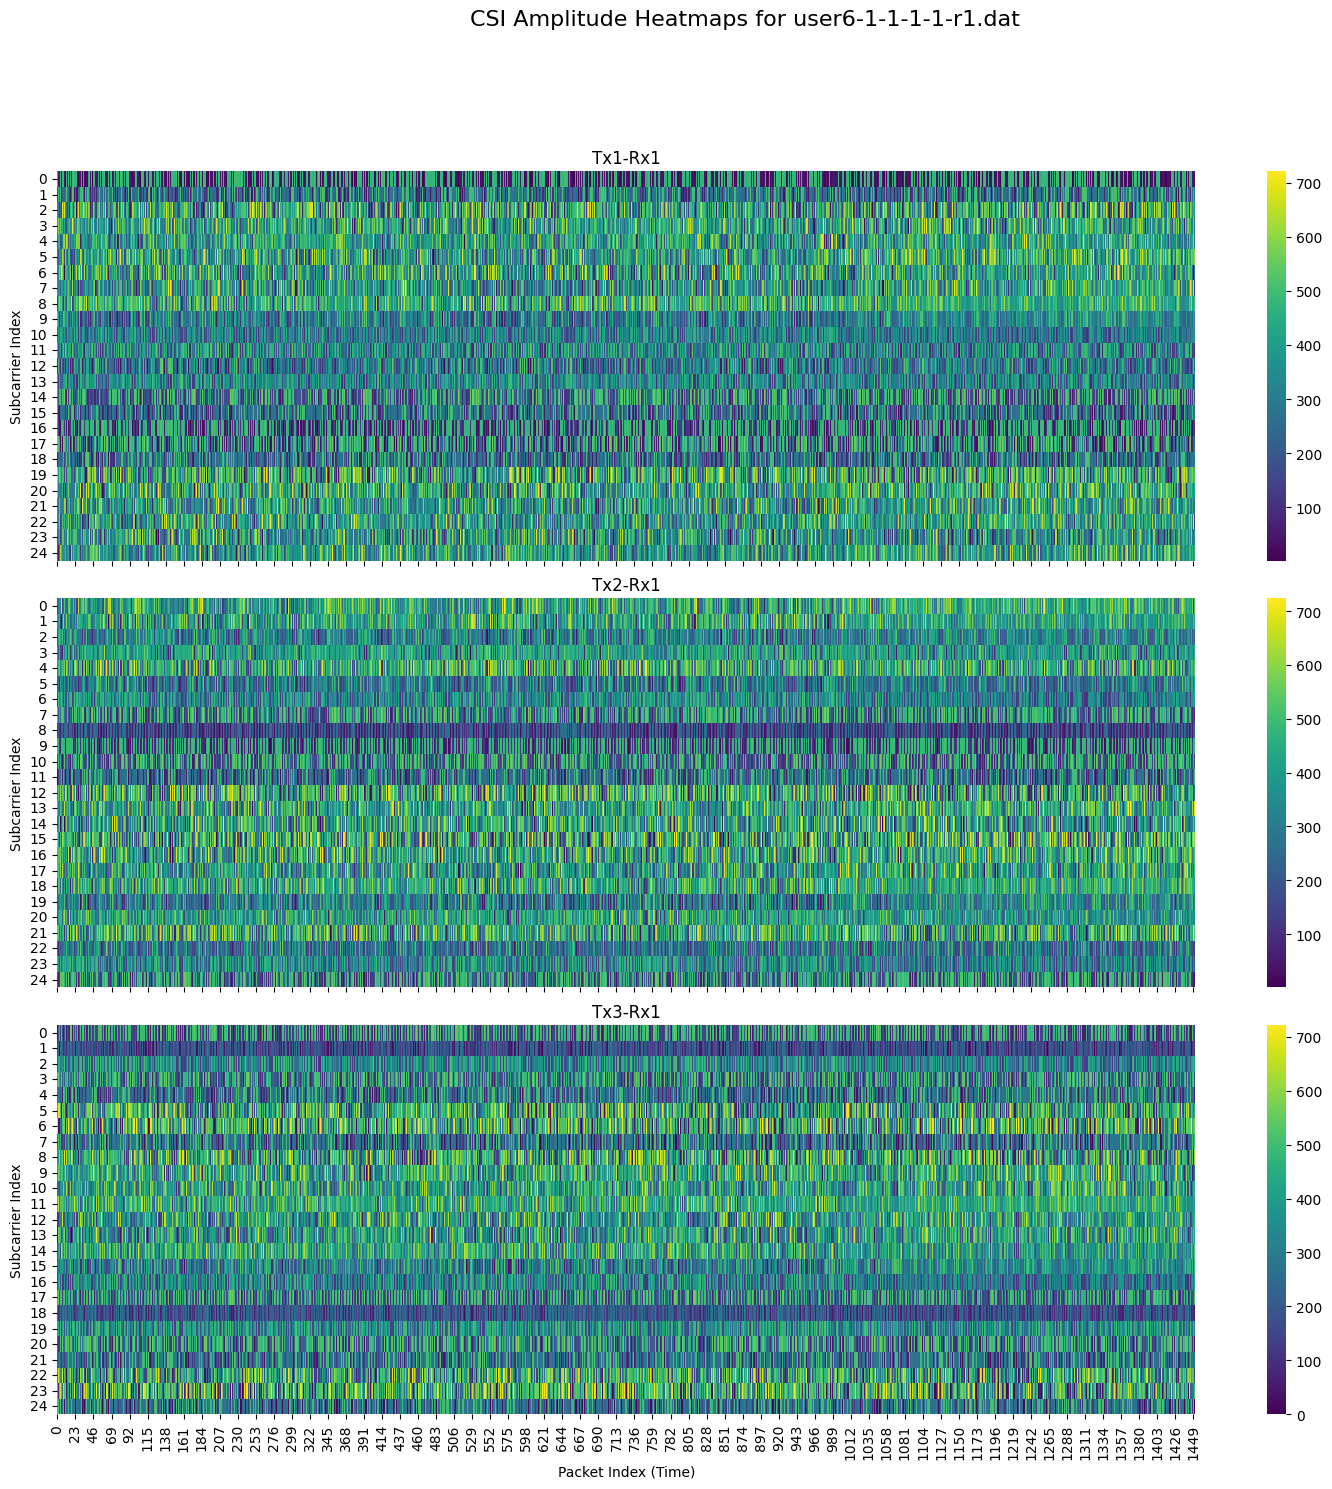

In [ ]:
other_file_names = [
    file_name
]

print(f"Preparing to generate heatmaps for {len(other_file_names)} files.")

for current_file in other_file_names:
    print(f"\nProcessing file: {current_file}")
    try:
        current_data_packets = read_widar_dat(current_file)

        plot_csi_heatmaps(current_data_packets, f'CSI Amplitude Heatmaps for {current_file}')
    except FileNotFoundError:
        print(f"Error: File not found at {current_file}.")
    except Exception as e:
        print(f"An error occurred while processing {current_file}: {e}")


Calculating average amplitudes for 1452 packets, 3 Tx, 1 Rx, 25 subcarriers.


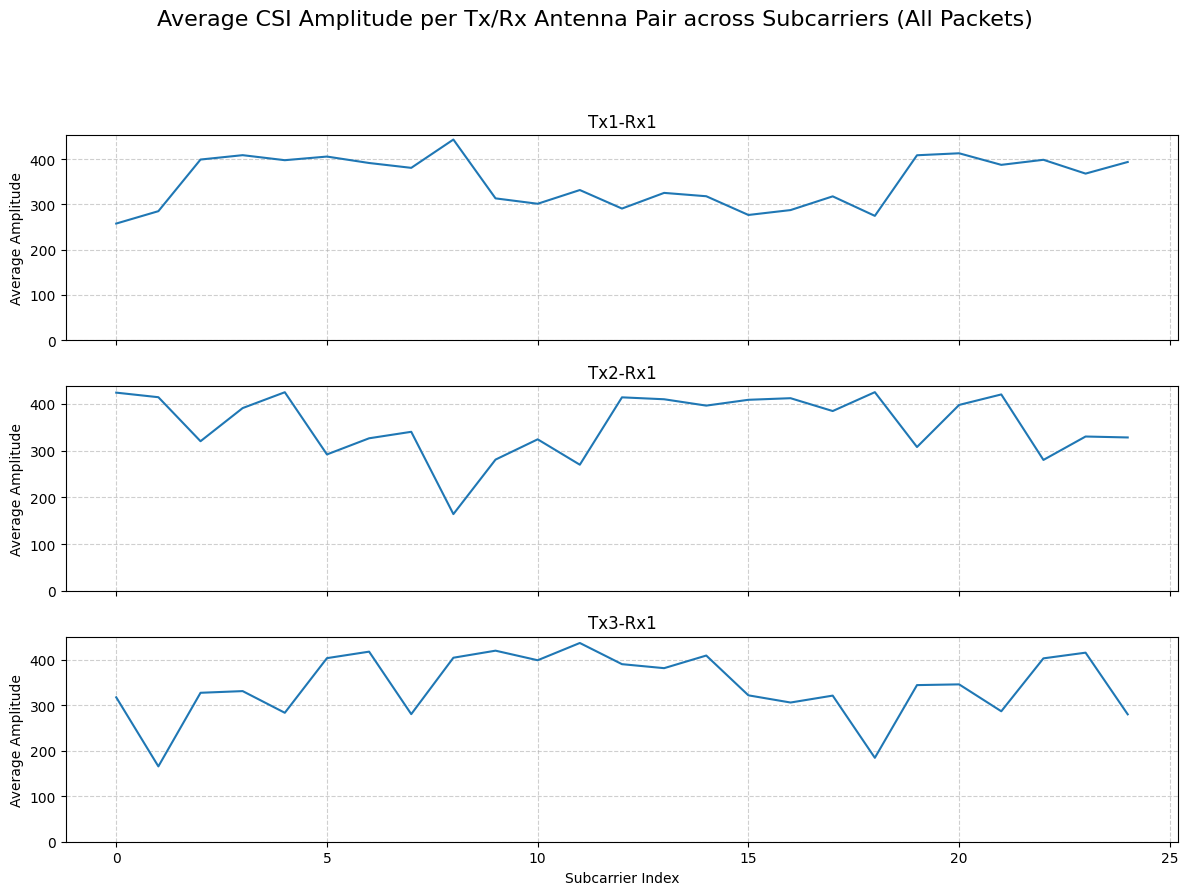

In [ ]:
if data_packets:
    num_packets = len(data_packets)

    first_valid_packet = None
    for packet in data_packets:
        if packet["n_tx"] > 0 and packet["n_rx"] > 0:
            first_valid_packet = packet
            break

    if not first_valid_packet:
        print("No valid CSI packets found to calculate average amplitude.")
    else:
        n_tx = first_valid_packet['n_tx']
        n_rx = first_valid_packet['n_rx']
        num_subcarriers = first_valid_packet['csi'].shape[2]

        print(f"Calculating average amplitudes for {num_packets} packets, {n_tx} Tx, {n_rx} Rx, {num_subcarriers} subcarriers.")

        all_amplitudes_per_pair = [np.zeros((num_subcarriers, num_packets)) for _ in range(n_tx * n_rx)]

        for packet_idx, packet in enumerate(data_packets):
            csi_matrix = packet['csi']
            if csi_matrix.shape == (n_tx, n_rx, num_subcarriers):
                amplitude = np.abs(csi_matrix)

                pair_idx = 0
                for tx_idx in range(n_tx):
                    for rx_idx in range(n_rx):
                        all_amplitudes_per_pair[pair_idx][:, packet_idx] = amplitude[tx_idx, rx_idx, :]
                        pair_idx += 1
        average_amplitudes = []
        for amplitudes_2d_array in all_amplitudes_per_pair:
            average_amplitudes.append(np.mean(amplitudes_2d_array, axis=1))
        fig, axes = plt.subplots(n_tx * n_rx, 1, figsize=(12, 3 * (n_tx * n_rx)), sharex=True)

        if n_tx * n_rx == 1:
            axes = [axes]

        fig.suptitle('Average CSI Amplitude per Tx/Rx Antenna Pair across Subcarriers (All Packets)', fontsize=16, y=1.02)

        pair_idx = 0
        for tx_idx in range(n_tx):
            for rx_idx in range(n_rx):
                ax = axes[pair_idx]
                ax.plot(average_amplitudes[pair_idx])
                ax.set_title(f'Tx{tx_idx+1}-Rx{rx_idx+1}')
                ax.set_ylabel('Average Amplitude')
                ax.set_ylim(bottom=0) # Ensure amplitude starts from 0
                ax.grid(True, linestyle='--', alpha=0.6)
                if pair_idx == (n_tx * n_rx) - 1:
                    ax.set_xlabel('Subcarrier Index')
                else:
                    ax.set_xlabel('')
                pair_idx += 1

        plt.tight_layout(rect=[0.0, 0.03, 1, 0.96])
        plt.show()

else:
    print("No CSI packets found to calculate average amplitude.")

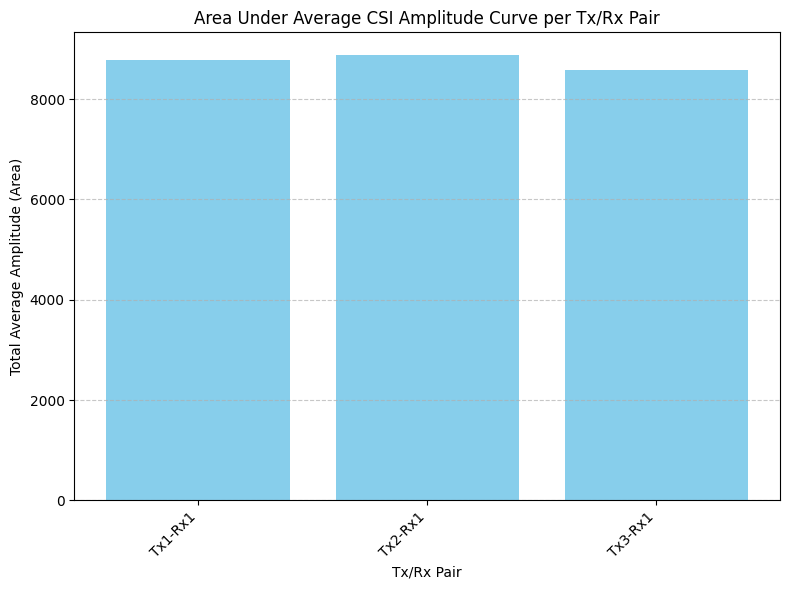

In [ ]:
if 'average_amplitudes' in locals() and average_amplitudes:
    areas_under_curve = []
    labels = []

    first_valid_packet = None
    if 'data_packets' in locals() and data_packets:
        for packet in data_packets:
            if packet["n_tx"] > 0 and packet["n_rx"] > 0:
                first_valid_packet = packet
                break

    if not first_valid_packet:
        print("Cannot determine Tx/Rx labels as no valid CSI packets were found.")
    else:
        n_tx_current = first_valid_packet['n_tx']
        n_rx_current = first_valid_packet['n_rx']

        pair_idx = 0
        for tx_idx in range(n_tx_current):
            for rx_idx in range(n_rx_current):
                area = np.sum(average_amplitudes[pair_idx])
                areas_under_curve.append(area)
                labels.append(f'Tx{tx_idx+1}-Rx{rx_idx+1}')
                pair_idx += 1

        fig_area, ax_area = plt.subplots(figsize=(8, 6))
        ax_area.bar(labels, areas_under_curve, color='skyblue')
        ax_area.set_title('Area Under Average CSI Amplitude Curve per Tx/Rx Pair')
        ax_area.set_xlabel('Tx/Rx Pair')
        ax_area.set_ylabel('Total Average Amplitude (Area)')
        ax_area.grid(axis='y', linestyle='--', alpha=0.7)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
else:
    print("Average amplitudes not found. Please run the previous cell to calculate them.")

In [ ]:
def extract_amplitude_features_from_packet(packet):
    features = {}
    csi_matrix = packet['csi']
    n_tx, n_rx, num_subcarriers = csi_matrix.shape

    amplitude = np.abs(csi_matrix)

    for tx_idx in range(n_tx):
        for rx_idx in range(n_rx):
            pair_amplitude = amplitude[tx_idx, rx_idx, :]

            features[f'Tx{tx_idx+1}_Rx{rx_idx+1}_mean_amp'] = np.mean(pair_amplitude)
            features[f'Tx{tx_idx+1}_Rx{rx_idx+1}_var_amp'] = np.var(pair_amplitude)
            features[f'Tx{tx_idx+1}_Rx{rx_idx+1}_min_amp'] = np.min(pair_amplitude)
            features[f'Tx{tx_idx+1}_Rx{rx_idx+1}_max_amp'] = np.max(pair_amplitude)

    return features

def extract_phase_features_from_packet(packet):
    features = {}
    csi_matrix = packet['csi']
    n_tx, n_rx, num_subcarriers = csi_matrix.shape

    phase = np.angle(csi_matrix)

    for tx_idx in range(n_tx):
        for rx_idx in range(n_rx):
            pair_phase = phase[tx_idx, rx_idx, :]

            features[f'Tx{tx_idx+1}_Rx{rx_idx+1}_mean_phase'] = np.mean(pair_phase)
            features[f'Tx{tx_idx+1}_Rx{rx_idx+1}_var_phase'] = np.var(pair_phase)
            features[f'Tx{tx_idx+1}_Rx{rx_idx+1}_min_phase'] = np.min(pair_phase)
            features[f'Tx{tx_idx+1}_Rx{rx_idx+1}_max_phase'] = np.max(pair_phase)

    return features

if 'data_packets' in locals() and data_packets:
    all_amplitude_features = []
    all_phase_features = []

    for packet in data_packets:
        if packet['n_tx'] > 0 and packet['n_rx'] > 0:
            amplitude_features_dict = extract_amplitude_features_from_packet(packet)
            all_amplitude_features.append(amplitude_features_dict)
            phase_features_dict = extract_phase_features_from_packet(packet)
            all_phase_features.append(phase_features_dict)
    features_df = pd.DataFrame(all_amplitude_features)
    phase_features_df = pd.DataFrame(all_phase_features)

    print(f"Extracted amplitude features for {len(features_df)} packets. Shape: {features_df.shape}")
    display(features_df.head())
    print(f"\nExtracted phase features for {len(phase_features_df)} packets. Shape: {phase_features_df.shape}")
    display(phase_features_df.head())
    combined_features_df = pd.concat([features_df, phase_features_df], axis=1)
    print(f"\nCombined amplitude and phase features. New shape: {combined_features_df.shape}")
    display(combined_features_df.head())

else:
    print("No CSI packets found to extract features from. Please ensure 'data_packets' is loaded.")

Extracted amplitude features for 1452 packets. Shape: (1452, 12)


,Tx1_Rx1_mean_amp,Tx1_Rx1_var_amp,Tx1_Rx1_min_amp,Tx1_Rx1_max_amp,Tx2_Rx1_mean_amp,Tx2_Rx1_var_amp,Tx2_Rx1_min_amp,Tx2_Rx1_max_amp,Tx3_Rx1_mean_amp,Tx3_Rx1_var_amp,Tx3_Rx1_min_amp,Tx3_Rx1_max_amp
0,378.374579,23207.717914,95.336247,630.232497,330.337612,26582.382351,25.000000,645.629151,315.636882,27484.558808,33.015148,714.177849
1,300.480880,22384.960892,40.012498,575.501520,350.876108,20202.996978,55.865911,526.103602,372.117921,38473.613217,28.000000,689.048619
2,348.169895,19508.764054,16.124515,525.543528,390.606523,17549.504003,45.011110,559.700813,340.883303,20125.373628,27.073973,534.059922
3,356.795602,29585.578493,35.000000,587.554253,341.547936,22457.687428,97.984693,577.259907,344.574273,31982.330075,15.264338,676.754756
4,335.428860,29180.879893,28.284271,637.822859,365.407643,29556.054210,12.165525,602.544604,377.595962,17068.049295,169.177422,666.580828



Extracted phase features for 1452 packets. Shape: (1452, 12)


,Tx1_Rx1_mean_phase,Tx1_Rx1_var_phase,Tx1_Rx1_min_phase,Tx1_Rx1_max_phase,Tx2_Rx1_mean_phase,Tx2_Rx1_var_phase,Tx2_Rx1_min_phase,Tx2_Rx1_max_phase,Tx3_Rx1_mean_phase,Tx3_Rx1_var_phase,Tx3_Rx1_min_phase,Tx3_Rx1_max_phase
0,-0.220314,2.571915,-2.944624,2.912297,0.394211,3.294303,-2.569023,3.141593,0.484919,3.164255,-3.126209,3.111299
1,0.250079,3.903234,-3.132997,3.125031,-0.084656,2.725239,-2.574542,3.135569,0.500260,2.375017,-2.386986,3.127814
2,0.256856,3.630651,-3.017238,3.064821,0.312987,3.046197,-2.903935,3.067874,0.222717,3.351046,-2.300771,3.093659
3,0.170141,3.556089,-2.823089,3.109785,-0.026591,3.026452,-2.934282,3.035395,0.832320,3.383270,-2.688567,3.048116
4,0.331511,3.812064,-3.119762,3.139509,0.542635,2.658420,-2.205530,3.112434,0.263076,3.155431,-2.980277,2.997055



Combined amplitude and phase features. New shape: (1452, 24)


,Tx1_Rx1_mean_amp,Tx1_Rx1_var_amp,Tx1_Rx1_min_amp,Tx1_Rx1_max_amp,Tx2_Rx1_mean_amp,Tx2_Rx1_var_amp,Tx2_Rx1_min_amp,Tx2_Rx1_max_amp,Tx3_Rx1_mean_amp,Tx3_Rx1_var_amp,...,Tx1_Rx1_min_phase,Tx1_Rx1_max_phase,Tx2_Rx1_mean_phase,Tx2_Rx1_var_phase,Tx2_Rx1_min_phase,Tx2_Rx1_max_phase,Tx3_Rx1_mean_phase,Tx3_Rx1_var_phase,Tx3_Rx1_min_phase,Tx3_Rx1_max_phase
0,378.374579,23207.717914,95.336247,630.232497,330.337612,26582.382351,25.000000,645.629151,315.636882,27484.558808,...,-2.944624,2.912297,0.394211,3.294303,-2.569023,3.141593,0.484919,3.164255,-3.126209,3.111299
1,300.480880,22384.960892,40.012498,575.501520,350.876108,20202.996978,55.865911,526.103602,372.117921,38473.613217,...,-3.132997,3.125031,-0.084656,2.725239,-2.574542,3.135569,0.500260,2.375017,-2.386986,3.127814
2,348.169895,19508.764054,16.124515,525.543528,390.606523,17549.504003,45.011110,559.700813,340.883303,20125.373628,...,-3.017238,3.064821,0.312987,3.046197,-2.903935,3.067874,0.222717,3.351046,-2.300771,3.093659
3,356.795602,29585.578493,35.000000,587.554253,341.547936,22457.687428,97.984693,577.259907,344.574273,31982.330075,...,-2.823089,3.109785,-0.026591,3.026452,-2.934282,3.035395,0.832320,3.383270,-2.688567,3.048116
4,335.428860,29180.879893,28.284271,637.822859,365.407643,29556.054210,12.165525,602.544604,377.595962,17068.049295,...,-3.119762,3.139509,0.542635,2.658420,-2.205530,3.112434,0.263076,3.155431,-2.980277,2.997055


In [ ]:
window_size = 25
windowed_features = []
for i in range(0, len(combined_features_df), window_size):
    window = combined_features_df.iloc[i : i + window_size]
    mean_features_in_window = window.mean()
    windowed_features.append(mean_features_in_window)
windowed_features_df = pd.DataFrame(windowed_features)

print(f"Original combined features shape: {combined_features_df.shape}")
print(f"Windowed features shape (window size = {window_size}): {windowed_features_df.shape}")

print("\nFirst 5 rows of the windowed features DataFrame:")
display(windowed_features_df.head())

Original combined features shape: (1452, 24)
Windowed features shape (window size = 25): (59, 24)

First 5 rows of the windowed features DataFrame:


,Tx1_Rx1_mean_amp,Tx1_Rx1_var_amp,Tx1_Rx1_min_amp,Tx1_Rx1_max_amp,Tx2_Rx1_mean_amp,Tx2_Rx1_var_amp,Tx2_Rx1_min_amp,Tx2_Rx1_max_amp,Tx3_Rx1_mean_amp,Tx3_Rx1_var_amp,...,Tx1_Rx1_min_phase,Tx1_Rx1_max_phase,Tx2_Rx1_mean_phase,Tx2_Rx1_var_phase,Tx2_Rx1_min_phase,Tx2_Rx1_max_phase,Tx3_Rx1_mean_phase,Tx3_Rx1_var_phase,Tx3_Rx1_min_phase,Tx3_Rx1_max_phase
0,345.180555,26794.863122,35.153097,625.162429,358.843677,25636.149078,62.333519,636.285675,343.942491,27028.232261,...,-2.927090,3.070790,0.186939,3.114208,-2.847691,3.041998,0.338920,3.181110,-2.893793,3.035432
1,350.800374,29166.464805,30.868734,640.777608,354.334258,25654.389620,65.179512,629.391271,342.805844,27204.085022,...,-2.872115,3.077634,0.078314,2.951932,-2.914021,2.951491,0.203110,3.198228,-2.876943,3.054146
2,345.222958,27597.058013,36.105512,621.073941,362.730316,26030.819529,69.420455,649.484379,340.052822,28580.259894,...,-2.891598,3.034261,0.058866,3.049367,-2.810867,2.975502,0.218329,3.101477,-2.889409,2.981689
3,349.586467,25544.057070,48.414339,623.063068,357.233473,26022.294175,58.419047,642.923090,345.196166,27940.955458,...,-2.896984,3.055068,0.069488,3.250720,-2.904563,2.995850,0.231482,3.018950,-2.819293,2.997929
4,350.300059,27703.356920,38.145485,648.904198,350.704013,28022.422049,45.482115,629.299035,340.074307,29654.452565,...,-2.826484,3.025130,0.152439,3.077750,-2.840314,3.038689,0.249155,3.275274,-2.924063,2.995244


FFT Implementation from SPOTFI paper 
 - np.fft could be used avoided to follow paper

In [ ]:

fft_window_size = 50
fft_overlap = 25
sampling_rate_hz = 100
all_fft_features = []
if 'data_packets' not in locals() or not data_packets:
    print("Error: 'data_packets' is empty or not found. Please ensure CSI data is parsed correctly.")
else:
    first_valid_packet = next((p for p in data_packets if p['n_tx'] > 0 and p['n_rx'] > 0), None)
    if first_valid_packet is None:
        print("Error: No valid CSI packets found in 'data_packets' with non-zero Tx/Rx.")
    else:
        n_tx, n_rx, num_subcarriers = first_valid_packet['csi'].shape
        valid_amplitudes = []
        for p in data_packets:
            if p['csi'].shape == (n_tx, n_rx, num_subcarriers):
                valid_amplitudes.append(np.abs(p['csi']))

        if not valid_amplitudes:
            print("Error: No valid amplitude data found after filtering packets by shape.")
        else:
            all_amplitudes_stacked = np.array(valid_amplitudes)
            num_total_packets = all_amplitudes_stacked.shape[0]

            print(f"Applying FFT windowing (size={fft_window_size} packets, overlap={fft_overlap} packets) to {num_total_packets} packets.")
            print(f"Extracting features for {n_tx} Tx, {n_rx} Rx, {num_subcarriers} subcarriers.")

            for i in range(0, num_total_packets - fft_window_size + 1, fft_window_size - fft_overlap):
                window_data = all_amplitudes_stacked[i : i + fft_window_size]

                window_fft_features = {}
                for tx_idx in range(n_tx):
                    for rx_idx in range(n_rx):
                        for sub_idx in range(num_subcarriers):
                            amplitude_time_series = window_data[:, tx_idx, rx_idx, sub_idx]
                            N = fft_window_size
                            T = 1.0 / sampling_rate_hz
                            yf = fft(amplitude_time_series)
                            xf = fftfreq(N, T)[:N//2]
                            magnitude = np.abs(yf[0:N//2])
                            if len(magnitude) > 0:
                                dominant_freq_idx = np.argmax(magnitude)
                                dominant_freq = xf[dominant_freq_idx]
                                dominant_freq_magnitude = magnitude[dominant_freq_idx]
                                mean_freq_magnitude = np.mean(magnitude)
                            else:
                                dominant_freq = 0.0
                                dominant_freq_magnitude = 0.0
                                mean_freq_magnitude = 0.0

                            window_fft_features[f'Tx{tx_idx+1}_Rx{rx_idx+1}_Sub{sub_idx+1}_dom_freq'] = dominant_freq
                            window_fft_features[f'Tx{tx_idx+1}_Rx{rx_idx+1}_Sub{sub_idx+1}_dom_freq_mag'] = dominant_freq_magnitude
                            window_fft_features[f'Tx{tx_idx+1}_Rx{rx_idx+1}_Sub{sub_idx+1}_mean_freq_mag'] = mean_freq_magnitude

                all_fft_features.append(window_fft_features)

            fft_features_df = pd.DataFrame(all_fft_features)

            print(f"\nNumber of original packets: {num_total_packets}")
            print(f"FFT window size: {fft_window_size}, Overlap: {fft_overlap}")
            print(f"Shape of FFT features DataFrame: {fft_features_df.shape}")
            print("\nFirst 5 rows of the FFT features DataFrame:")
            display(fft_features_df.head())

Applying FFT windowing (size=50 packets, overlap=25 packets) to 1452 packets.
Extracting features for 3 Tx, 1 Rx, 25 subcarriers.

Number of original packets: 1452
FFT window size: 50, Overlap: 25
Shape of FFT features DataFrame: (57, 225)

First 5 rows of the FFT features DataFrame:


,Tx1_Rx1_Sub1_dom_freq,Tx1_Rx1_Sub1_dom_freq_mag,Tx1_Rx1_Sub1_mean_freq_mag,Tx1_Rx1_Sub2_dom_freq,Tx1_Rx1_Sub2_dom_freq_mag,Tx1_Rx1_Sub2_mean_freq_mag,Tx1_Rx1_Sub3_dom_freq,Tx1_Rx1_Sub3_dom_freq_mag,Tx1_Rx1_Sub3_mean_freq_mag,Tx1_Rx1_Sub4_dom_freq,...,Tx3_Rx1_Sub22_mean_freq_mag,Tx3_Rx1_Sub23_dom_freq,Tx3_Rx1_Sub23_dom_freq_mag,Tx3_Rx1_Sub23_mean_freq_mag,Tx3_Rx1_Sub24_dom_freq,Tx3_Rx1_Sub24_dom_freq_mag,Tx3_Rx1_Sub24_mean_freq_mag,Tx3_Rx1_Sub25_dom_freq,Tx3_Rx1_Sub25_dom_freq_mag,Tx3_Rx1_Sub25_mean_freq_mag
0,0.0,11499.227158,1797.967008,0.0,14686.407775,1490.453471,0.0,19185.009212,1936.506239,0.0,...,1338.382927,0.0,20221.319811,1923.853771,0.0,19874.199565,2066.009000,0.0,14550.377676,1447.914804
1,0.0,9691.517234,1687.309446,0.0,15203.463265,1517.104884,0.0,20882.316820,1863.880833,0.0,...,1460.665884,0.0,20120.121226,1976.663198,0.0,21145.701054,2064.001360,0.0,14213.116633,1495.806851
2,0.0,12140.770762,1866.430578,0.0,14462.571507,1471.356651,0.0,19841.994215,1863.467184,0.0,...,1539.296685,0.0,20352.549588,1958.253347,0.0,20906.562912,2044.823768,0.0,13716.367805,1510.770245
3,0.0,14345.453208,1876.870366,0.0,13238.930650,1458.292621,0.0,20492.334621,1998.849541,0.0,...,1493.569090,0.0,20120.760500,1868.807101,0.0,21001.188648,2168.622181,0.0,13761.433314,1408.519180
4,0.0,13151.637809,1958.820874,0.0,12924.076785,1293.880149,0.0,21940.278748,1812.137769,0.0,...,1616.391640,0.0,18862.838503,1823.852278,0.0,21446.377749,2166.677538,0.0,13636.492450,1366.801077


Trying PCA from DEEPFI paper

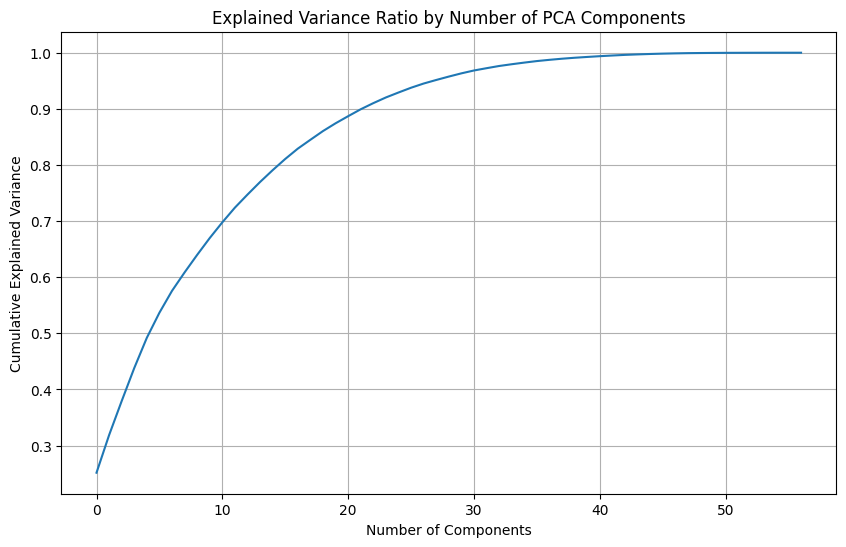

Original number of features: 225


In [ ]:
pca = PCA()
pca.fit(fft_features_df)

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance Ratio by Number of PCA Components')
plt.grid(True)
plt.show()

print(f"Original number of features: {fft_features_df.shape[1]}")

In [ ]:
n_components_95_var = np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.95)[0][0] + 1
n_components_selected = min(n_components_95_var, fft_features_df.shape[1]) # Ensure it doesn't exceed total features
print(f"Selected number of components to explain ~95% variance: {n_components_selected}")
pca_final = PCA(n_components=n_components_selected)
fft_features_pca = pca_final.fit_transform(fft_features_df)
fft_features_pca_df = pd.DataFrame(fft_features_pca, columns=[f'PC_{i+1}' for i in range(n_components_selected)])
print(f"Shape of FFT features after PCA: {fft_features_pca_df.shape}")
print("First 5 rows of PCA-transformed FFT features:")
display(fft_features_pca_df.head())

Selected number of components to explain ~95% variance: 28
Shape of FFT features after PCA: (57, 28)
First 5 rows of PCA-transformed FFT features:


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_19,PC_20,PC_21,PC_22,PC_23,PC_24,PC_25,PC_26,PC_27,PC_28
0,-3782.801372,-930.869769,3478.269710,-582.069422,155.490316,-1121.524282,1953.930734,-328.840105,-1858.483910,-447.740183,...,-2674.685916,1163.243702,-695.927770,-294.681225,-318.461431,180.548717,-215.772851,408.781357,-208.198766,1303.417410
1,-3049.789138,-868.607080,2225.985952,-1307.086568,-2251.990665,-55.850039,1910.848488,-1345.812829,1671.652840,545.419751,...,1402.332530,296.321842,-1485.294786,-671.821143,182.842407,1845.630613,-245.725314,-1772.374850,849.434323,-427.683651
2,-4145.977988,-1857.944527,-614.643120,-2631.374386,-154.257864,1393.532757,2875.646458,-2044.659403,302.855370,690.647530,...,3355.848941,-1340.897937,-189.128513,108.300931,572.944078,-53.569844,210.639617,231.354996,462.351321,1174.398182
3,-3602.043839,-220.750486,-3097.927903,-3451.453249,3840.979089,2510.136952,1793.798481,-483.001433,-2147.695648,1513.627596,...,2856.240612,-1204.602276,1003.757668,737.840740,312.647017,575.684648,-657.348169,1313.555513,-62.791989,401.175336
4,-635.644370,375.803492,8.471489,-463.583270,4178.693441,60.002896,25.086419,2795.810273,16.021773,2543.247640,...,-1163.726380,232.265875,-55.947819,1049.888161,-882.087152,705.611664,605.688651,-188.702141,-67.102593,-1849.799276


In [ ]:
num_samples = fft_features_df.shape[0]
dummy_labels = np.random.randint(0, 2, num_samples)
print(f"Generated {len(dummy_labels)} dummy labels for {num_samples} samples.")
print(f"Dummy label distribution: {pd.Series(dummy_labels).value_counts()}")

Generated 57 dummy labels for 57 samples.
Dummy label distribution: 1    30
0    27
Name: count, dtype: int64


In [ ]:
X_original = fft_features_df
y = dummy_labels

X_train_orig, X_test_orig, y_train, y_test = train_test_split(
    X_original, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Original features training shape: {X_train_orig.shape}")
print(f"Original features testing shape: {X_test_orig.shape}")
model_orig = RandomForestClassifier(n_estimators=100, random_state=42)
model_orig.fit(X_train_orig, y_train)
y_pred_orig = model_orig.predict(X_test_orig)
accuracy_orig = accuracy_score(y_test, y_pred_orig)
report_orig = classification_report(y_test, y_pred_orig)

print(f"\n--- Performance WITHOUT PCA ---")
print(f"Accuracy: {accuracy_orig:.4f}")
print("Classification Report:")
print(report_orig)

Original features training shape: (39, 225)
Original features testing shape: (18, 225)

--- Performance WITHOUT PCA ---
Accuracy: 0.6111
Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.67      0.63         9
           1       0.62      0.56      0.59         9

    accuracy                           0.61        18
   macro avg       0.61      0.61      0.61        18
weighted avg       0.61      0.61      0.61        18



In [ ]:
X_pca = fft_features_pca_df
X_train_pca, X_test_pca, _, _ = train_test_split(
    X_pca, y, test_size=0.3, random_state=42, stratify=y
)

print(f"PCA features training shape: {X_train_pca.shape}")
print(f"PCA features testing shape: {X_test_pca.shape}")
model_pca = RandomForestClassifier(n_estimators=100, random_state=42)
model_pca.fit(X_train_pca, y_train)
y_pred_pca = model_pca.predict(X_test_pca)
accuracy_pca = accuracy_score(y_test, y_pred_pca)
report_pca = classification_report(y_test, y_pred_pca)

print(f"\n--- Performance WITH PCA ---")
print(f"Accuracy: {accuracy_pca:.4f}")
print("Classification Report:")
print(report_pca)

PCA features training shape: (39, 28)
PCA features testing shape: (18, 28)

--- Performance WITH PCA ---
Accuracy: 0.5556
Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.44      0.50         9
           1       0.55      0.67      0.60         9

    accuracy                           0.56        18
   macro avg       0.56      0.56      0.55        18
weighted avg       0.56      0.56      0.55        18



In [ ]:
print(f"\n--- Final Performance Comparison (Dummy Data) ---")
print(f"Model WITHOUT PCA Accuracy: {accuracy_orig:.4f}")
print(f"Model WITH PCA Accuracy:    {accuracy_pca:.4f}")

if accuracy_pca > accuracy_orig:
    print("PCA improved the model's accuracy in this simulation.")
elif accuracy_pca < accuracy_orig:
    print("PCA slightly reduced the model's accuracy in this simulation (might vary with real data/hyperparameters).")
else:
    print("PCA had no significant impact on accuracy in this simulation.")


--- Final Performance Comparison (Dummy Data) ---
Model WITHOUT PCA Accuracy: 0.6111
Model WITH PCA Accuracy:    0.5556
PCA slightly reduced the model's accuracy in this simulation (might vary with real data/hyperparameters).
